# Figure S10: Batch-effect heatmap across all 33 microstructural metrics

Replicates the Figure 3 heatmap style using all config-listed microstructural metrics, with spacers between bundle categories (columns) and processing software blocks (rows).


In [59]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(arrow)
  library(viridis)
})

config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file.exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) {
  stop("Could not locate config.json. Set CONFIG_PATH or run from within the project tree.")
}

config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s10_dir <- fs::path(project_root, "figures", "Supplement", "FigureS10")
fs::dir_create(figure_s10_dir, recurse = TRUE)

batch_effects_rds <- fs::path(project_root, "data", "batch_effects", "batch_effects_all_outputs.rds")
if (!file.exists(batch_effects_rds)) {
  stop("Missing pooled batch effects file: ", batch_effects_rds)
}

df_effects <- readRDS(batch_effects_rds)
if (!is.data.frame(df_effects)) stop("Batch effects object is not a data.frame: ", batch_effects_rds)
if ("output_type" %in% names(df_effects)) {
  df_effects <- df_effects %>% filter(output_type == "batch_effects")
}

qc_target <- "no_quality"
metrics_keep <- config$microstructural_metrics
if (length(metrics_keep) != 33) {
  message("[FigureS10] config$microstructural_metrics has ", length(metrics_keep), " metrics (expected 33). Continuing with config-defined list.")
}


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS10/S10_batch_effect_heatmap_all_microstructure.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS10/S10_batch_effect_heatmap_all_microstructure.png



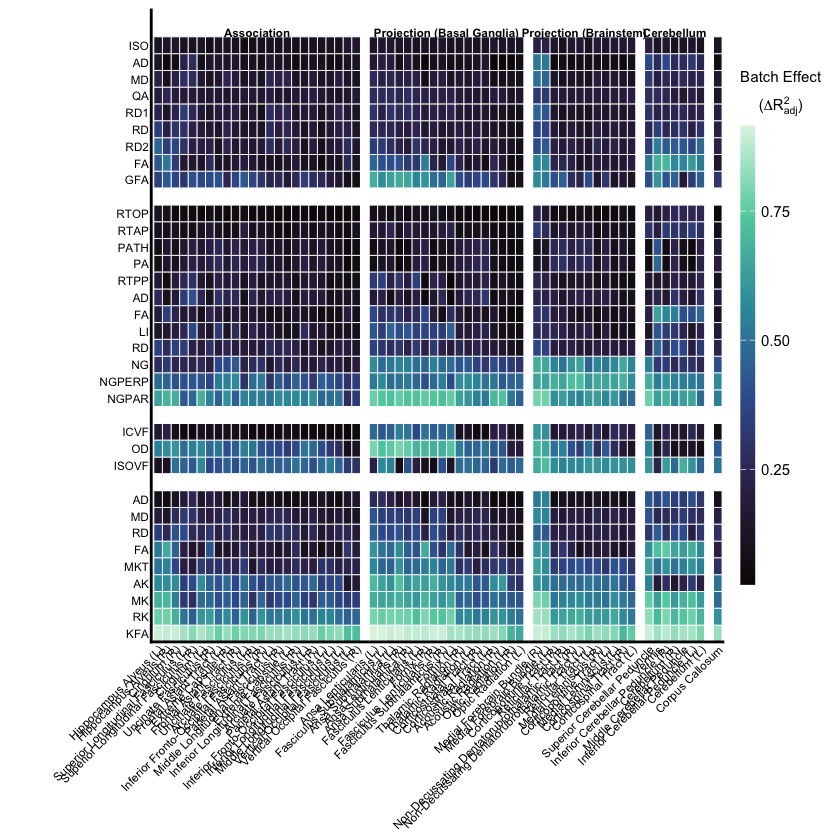

In [60]:
software_order <- c("DIPY", "AMICO", "TORTOISE", "DSI Studio")
category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Commissure"
)

metric_display <- setNames(
  ifelse(
    str_detect(metrics_keep, "_"),
    str_to_upper(str_remove(metrics_keep, "^[^_]+_")),
    str_to_upper(metrics_keep)
  ),
  metrics_keep
)

df_heat <- df_effects %>%
  filter(
    source == "raw",
    qc_covariate == qc_target,
    metric %in% metrics_keep,
    !is.na(bundle), !is.na(bundle_category), !is.na(effect_size)
  ) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    ),
    bundle_clean = bundle,
    bundle_category = case_when(
      bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
      bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
      TRUE ~ bundle_category
    ),
    bundle_clean = bundle_clean %>%
      str_replace("FrontoOccipital", "Fronto-Occipital") %>%
      str_replace("NonDecussating", "Non-Decussating") %>%
      str_replace("L$", " (L)") %>%
      str_replace("R$", " (R)") %>%
      str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  ) %>%
  filter(software %in% software_order)

if (nrow(df_heat) == 0) stop("No rows for FigureS10 heatmap after filtering.")

metric_rank <- df_heat %>%
  group_by(software, metric) %>%
  summarise(mean_effect = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(software = factor(software, levels = software_order)) %>%
  arrange(software, desc(mean_effect), metric)

metric_levels <- c()
for (sw in software_order) {
  sw_metrics <- metric_rank %>% filter(software == sw) %>% pull(metric)
  if (length(sw_metrics) > 0) {
    metric_levels <- c(metric_levels, sw_metrics, paste0("spacer_", sw))
  }
}
metric_levels <- metric_levels[!grepl("^spacer_DSI Studio$", metric_levels)]

bundle_rank <- df_heat %>%
  group_by(bundle_category, bundle_clean) %>%
  summarise(mean_effect = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(bundle_category = factor(bundle_category, levels = category_order)) %>%
  arrange(bundle_category, desc(mean_effect), bundle_clean)

bundle_levels <- c()
for (cat in category_order) {
  cat_bundles <- bundle_rank %>% filter(bundle_category == cat) %>% pull(bundle_clean)
  if (length(cat_bundles) > 0) {
    bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
  }
}
bundle_levels <- bundle_levels[!grepl("^spacer_Commissure$", bundle_levels)]

bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
cat_positions <- bundle_rank %>%
  group_by(bundle_category) %>%
  summarise(
    xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmid = mean(c(xmin, xmax)),
    .groups = "drop"
  ) %>%
  filter(bundle_category != "Commissure")

spacer_rows <- expand.grid(
  bundle_clean = bundle_levels,
  metric = metric_levels[grepl("^spacer_", metric_levels)],
  stringsAsFactors = FALSE
) %>%
  mutate(effect_size = NA_real_)

spacer_cols <- expand.grid(
  bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
  metric = metric_levels,
  stringsAsFactors = FALSE
) %>%
  mutate(effect_size = NA_real_)

df_plot <- bind_rows(
  df_heat %>% select(bundle_clean, metric, effect_size),
  spacer_rows,
  spacer_cols
) %>%
  distinct(bundle_clean, metric, .keep_all = TRUE) %>%
  mutate(
    bundle_clean = factor(bundle_clean, levels = bundle_levels),
    metric = factor(metric, levels = metric_levels)
  )

x_labels <- levels(df_plot$bundle_clean)
x_labels[grepl("^spacer_", x_labels)] <- ""
software_label_hjust <- 1.22
software_label_left_margin <- 60

y_levels <- levels(df_plot$metric)
y_labels <- ifelse(
  grepl("^spacer_", y_levels),
  "",
  unname(metric_display[y_levels])
)
y_labels[is.na(y_labels)] <- y_levels[is.na(y_labels)]

y_index_df <- tibble(metric = metric_levels, y_id = seq_along(metric_levels)) %>%
  filter(!grepl("^spacer_", metric)) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    )
  )

software_centers <- y_index_df %>%
  group_by(software) %>%
  summarise(y_mid = mean(y_id), .groups = "drop") %>%
  filter(software %in% software_order)

p_s10 <- ggplot(df_plot, aes(x = bundle_clean, y = metric, fill = effect_size)) +
  geom_tile(color = "white", linewidth = 0.25) +
  scale_fill_viridis_c(
    option = "mako",
    na.value = "white",
    name = expression(atop("Batch Effect", "(" * Delta * R[adj]^2 * ")"))
  ) +
  guides(fill = guide_colorbar(
    barheight = grid::unit(length(metric_levels[!grepl("^spacer_", metric_levels)]) * 0.58, "lines"),
    barwidth = grid::unit(0.62, "lines")
  )) +
  scale_x_discrete(labels = x_labels, expand = expansion(add = c(0.8, 0.6))) +
  scale_y_discrete(labels = y_labels, expand = expansion(mult = c(0, 0.06))) +
  #geom_text(
  #  data = software_centers,
  #  aes(x = -Inf, y = y_mid, label = software),
  #  inherit.aes = FALSE,
  #  hjust = software_label_hjust,
  #  vjust = 0.5,
  #  fontface = "bold",
  #  size = 2.5
  #) +
  coord_cartesian(clip = "off") +
  labs(x = NULL, y = NULL, title = NULL) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 7,
    axis_text_pt = 7,
    legend_title_pt = 9,
    legend_text_pt = 9,
    base_size_pt = 7
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.margin = margin(t = 6, r = 8, b = 6, l = software_label_left_margin)
  )


y_top <- length(metric_levels) + 0.75
for (i in seq_len(nrow(cat_positions))) {
  p_s10 <- p_s10 + annotate(
    "text",
    x = cat_positions$xmid[i],
    y = y_top,
    label = cat_positions$bundle_category[i],
    family = font_family_use,
    size = 7 / .pt,
    fontface = "bold"
  )
}

p_s10

save_plot_outputs(
  plot_obj = p_s10,
  stub = "S10_batch_effect_heatmap_all_microstructure",
  out_dir = figure_s10_dir,
  width_in = 14,
  height_in = 11
)
